# MLOps Assignment 1: End-to-End ML Model Development
## Heart Disease Prediction - UCI Dataset



---
## Task 1: Data Acquisition & Exploratory Data Analysis (EDA)
---

### 1.1 Install Dependencies & Import Libraries

In [1]:
# Install required packages
%pip install -q ucimlrepo mlflow scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
import mlflow
import mlflow.sklearn
import pickle
import json
import os

# Set style for plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
print('All libraries imported successfully!')

All libraries imported successfully!


### 1.2 Data Acquisition from UCI Repository

In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch the Heart Disease dataset (UCI ID = 45)
heart_disease = fetch_ucirepo(id=45)

# Access features and targets
X = heart_disease.data.features
y = heart_disease.data.targets

# Print dataset metadata
print(f"Dataset: {heart_disease.metadata.name}")
print(f"UCI ID: {heart_disease.metadata.uci_id}")
print(f"Number of instances: {heart_disease.metadata.num_instances}")
print(f"Number of features: {heart_disease.metadata.num_features}")
print(f"\nSummary:\n{heart_disease.metadata.additional_info.summary}")

Dataset: Heart Disease
UCI ID: 45
Number of instances: 303
Number of features: 13

Summary:
This database contains 76 attributes, but all published experiments refer to using a subset of 14 of them.  In particular, the Cleveland database is the only one that has been used by ML researchers to date.  The "goal" field refers to the presence of heart disease in the patient.  It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).  
   
The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

One file has been "processed", that one containing the Cleveland database.  All four unprocessed files also exist in this directory.

To see Test Costs (donated by Peter Turney), please see the folder "Costs" 


In [4]:
# Combine into a single DataFrame
df = X.copy()
df['target'] = y.values

# The target has values 0-4; convert to binary (0 = no disease, 1 = disease present)
df['target'] = (df['target'] > 0).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
df.head()

Dataset shape: (303, 14)

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [5]:
# Variable info from UCI
print(heart_disease.variables)

        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2              

### 1.3 Data Cleaning & Preprocessing

In [6]:
# Check for missing values
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"\nDataset info:")
df.info()

Missing values per column:
ca      4
thal    2
dtype: int64

Total missing: 6

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [7]:
# Handle missing values
# For numeric columns: fill with median
# For categorical columns: fill with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"  Filled '{col}' missing values with median: {median_val}")
        else:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"  Filled '{col}' missing values with mode: {mode_val}")

# Ensure all feature columns are numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any remaining NaN rows after coercion
rows_before = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nRows dropped after numeric coercion: {rows_before - len(df)}")
print(f"Final dataset shape: {df.shape}")
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")

  Filled 'ca' missing values with median: 0.0
  Filled 'thal' missing values with median: 3.0

Rows dropped after numeric coercion: 0
Final dataset shape: (303, 14)

Missing values remaining: 0


In [8]:
# Save cleaned dataset for reproducibility
df.to_csv('heart_disease_cleaned.csv', index=False)
print("Cleaned dataset saved to 'heart_disease_cleaned.csv'")
print(f"\nBasic statistics:")
df.describe().round(2)

Cleaned dataset saved to 'heart_disease_cleaned.csv'

Basic statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.66,4.72,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


### 1.4 Exploratory Data Analysis (EDA)

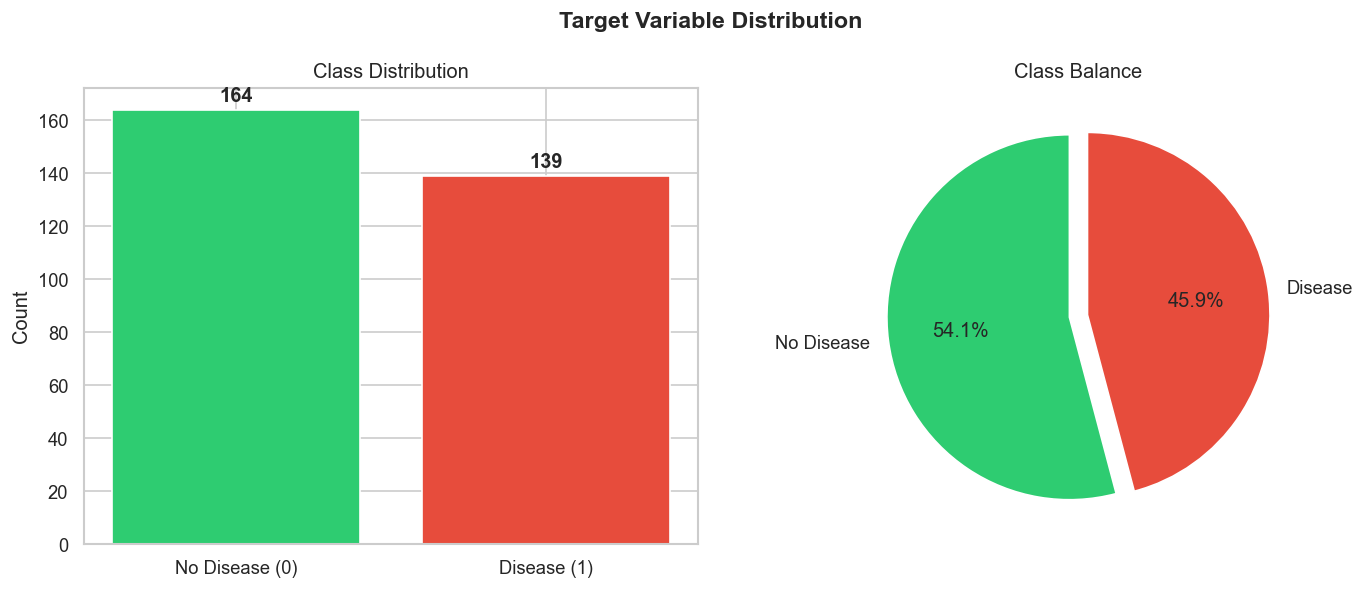

Class 0 (No Disease): 164 (54.1%)
Class 1 (Disease):    139 (45.9%)


In [9]:
# --- Class Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(target_counts.index, target_counts.values, color=colors)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
for i, v in enumerate(target_counts.values):
    axes[0].text(target_counts.index[i], v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Class Balance')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Class 0 (No Disease): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Class 1 (Disease):    {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

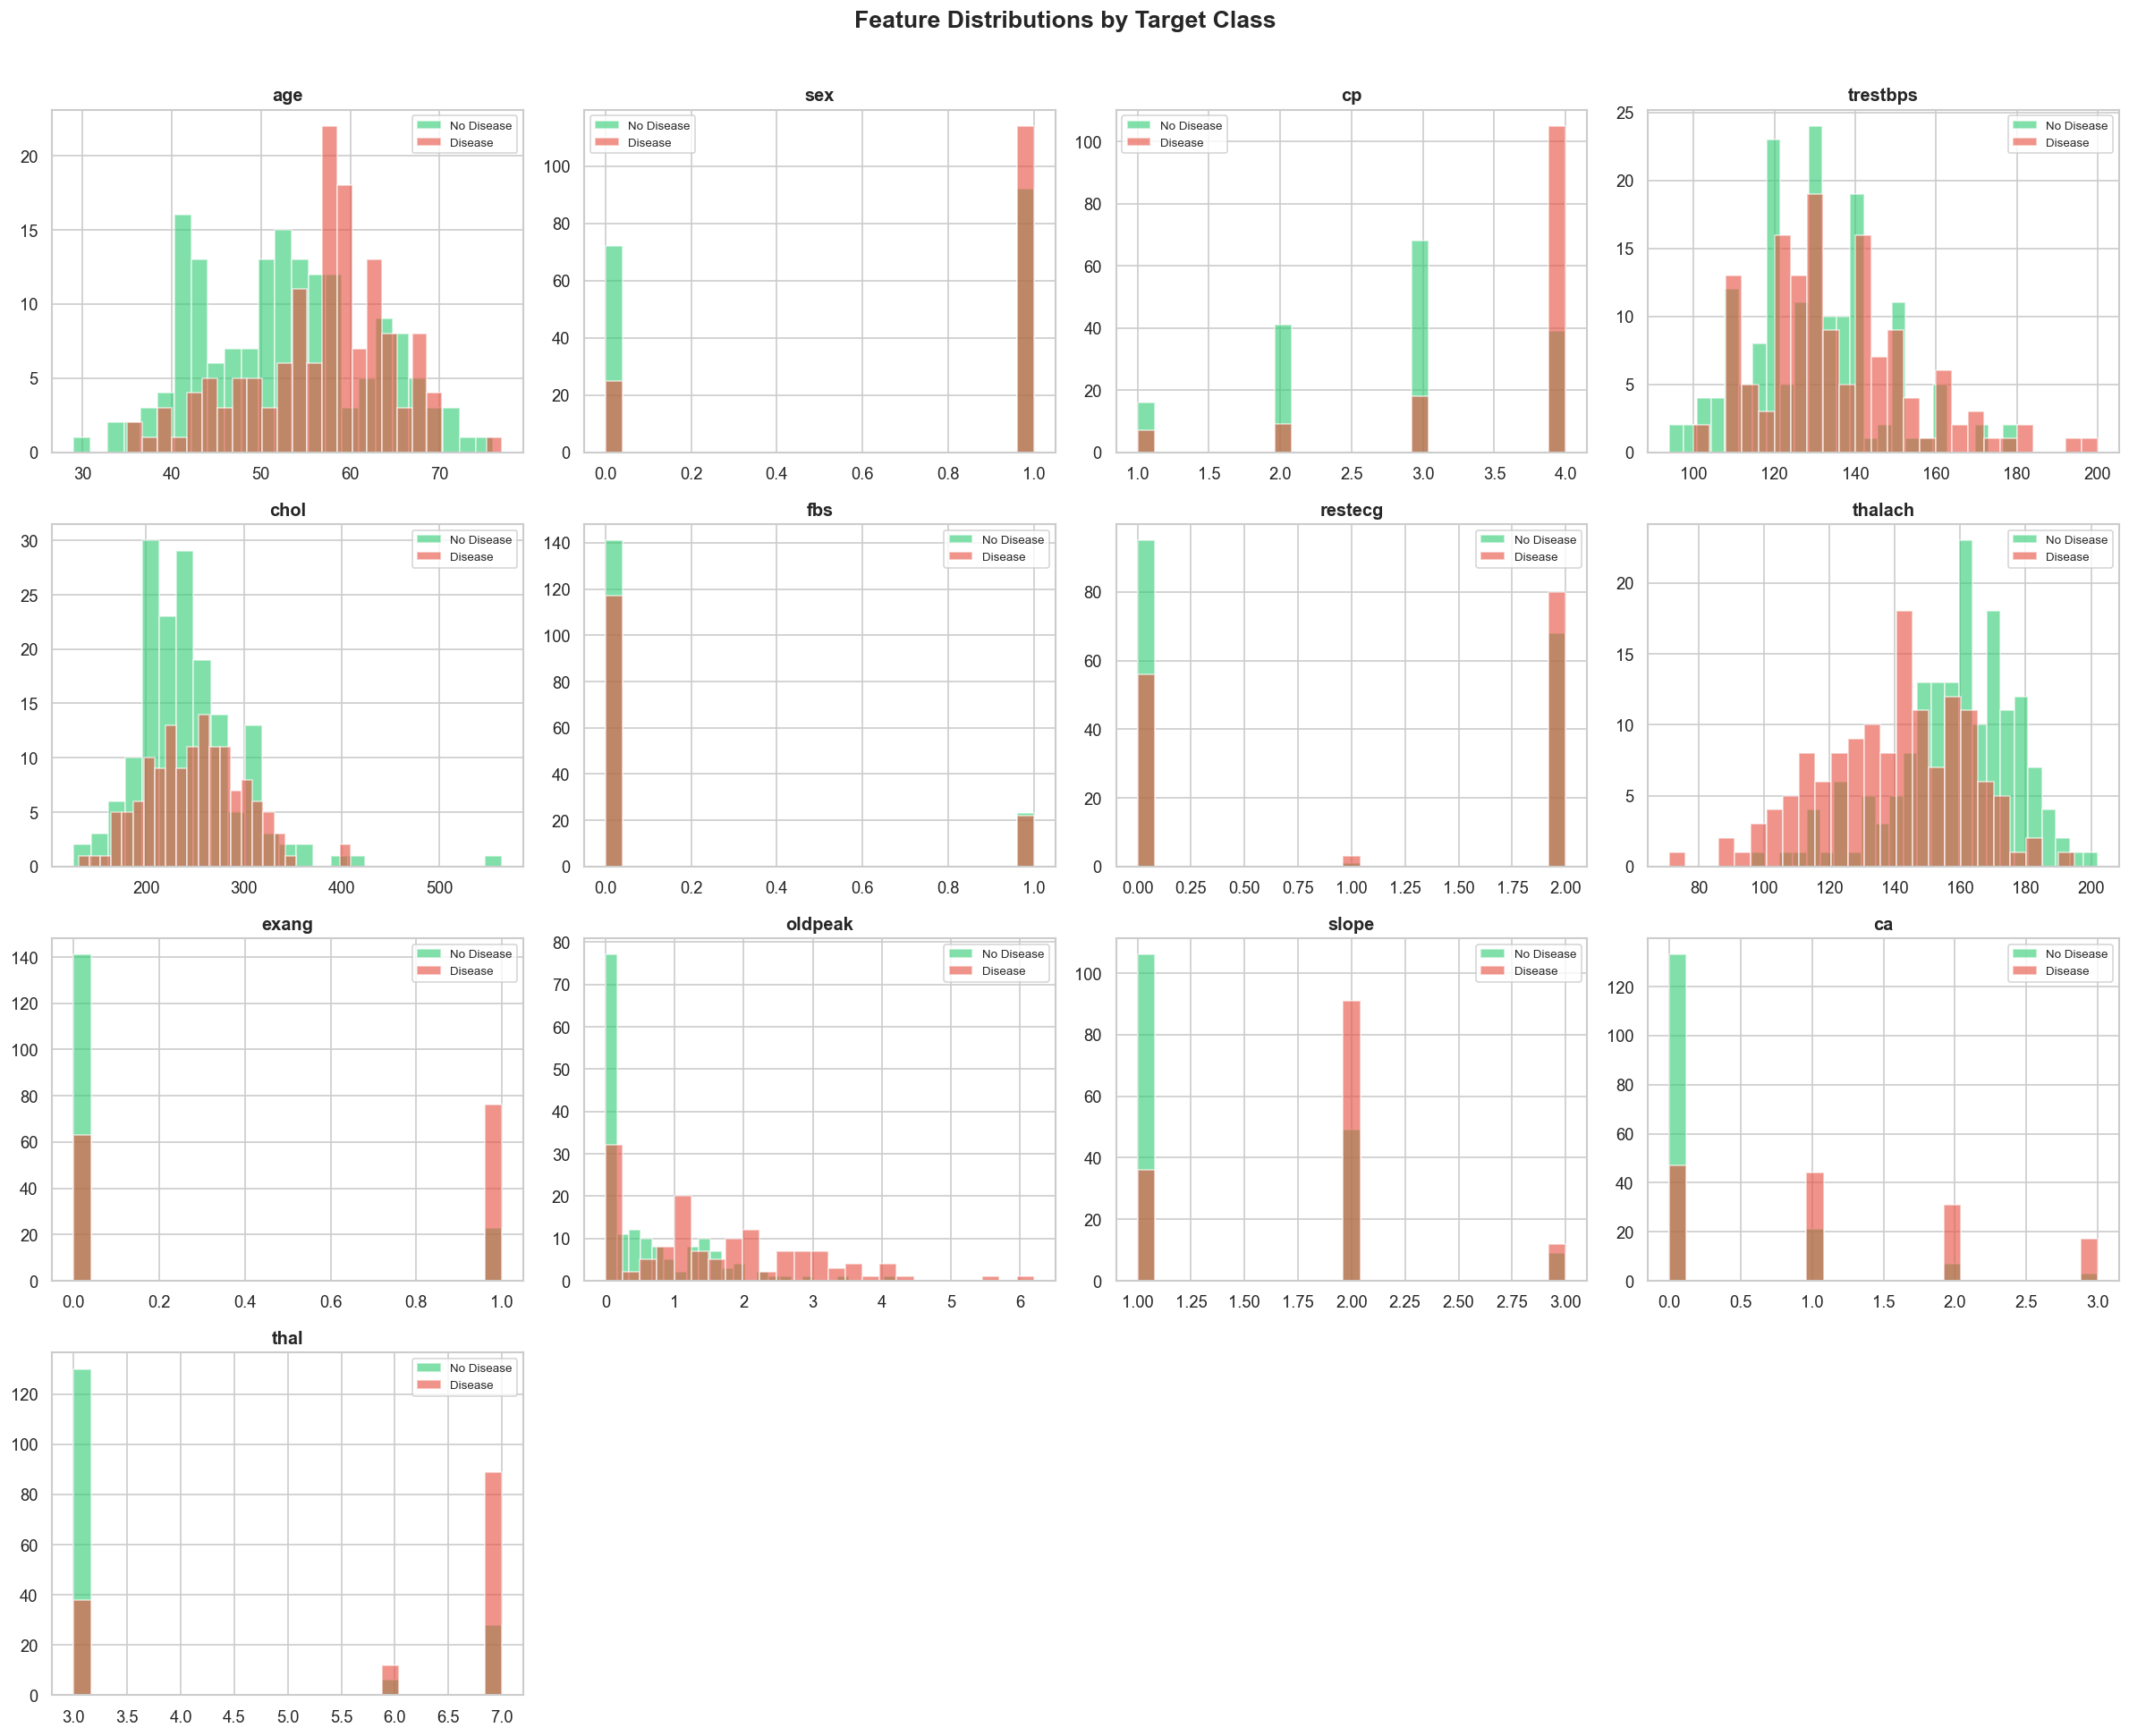

In [10]:
# --- Feature Distributions (Histograms) ---
feature_cols = [c for c in df.columns if c != 'target']
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    df[df['target'] == 0][col].hist(ax=ax, bins=25, alpha=0.6, color='#2ecc71', label='No Disease')
    df[df['target'] == 1][col].hist(ax=ax, bins=25, alpha=0.6, color='#e74c3c', label='Disease')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Target Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('screenshots/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

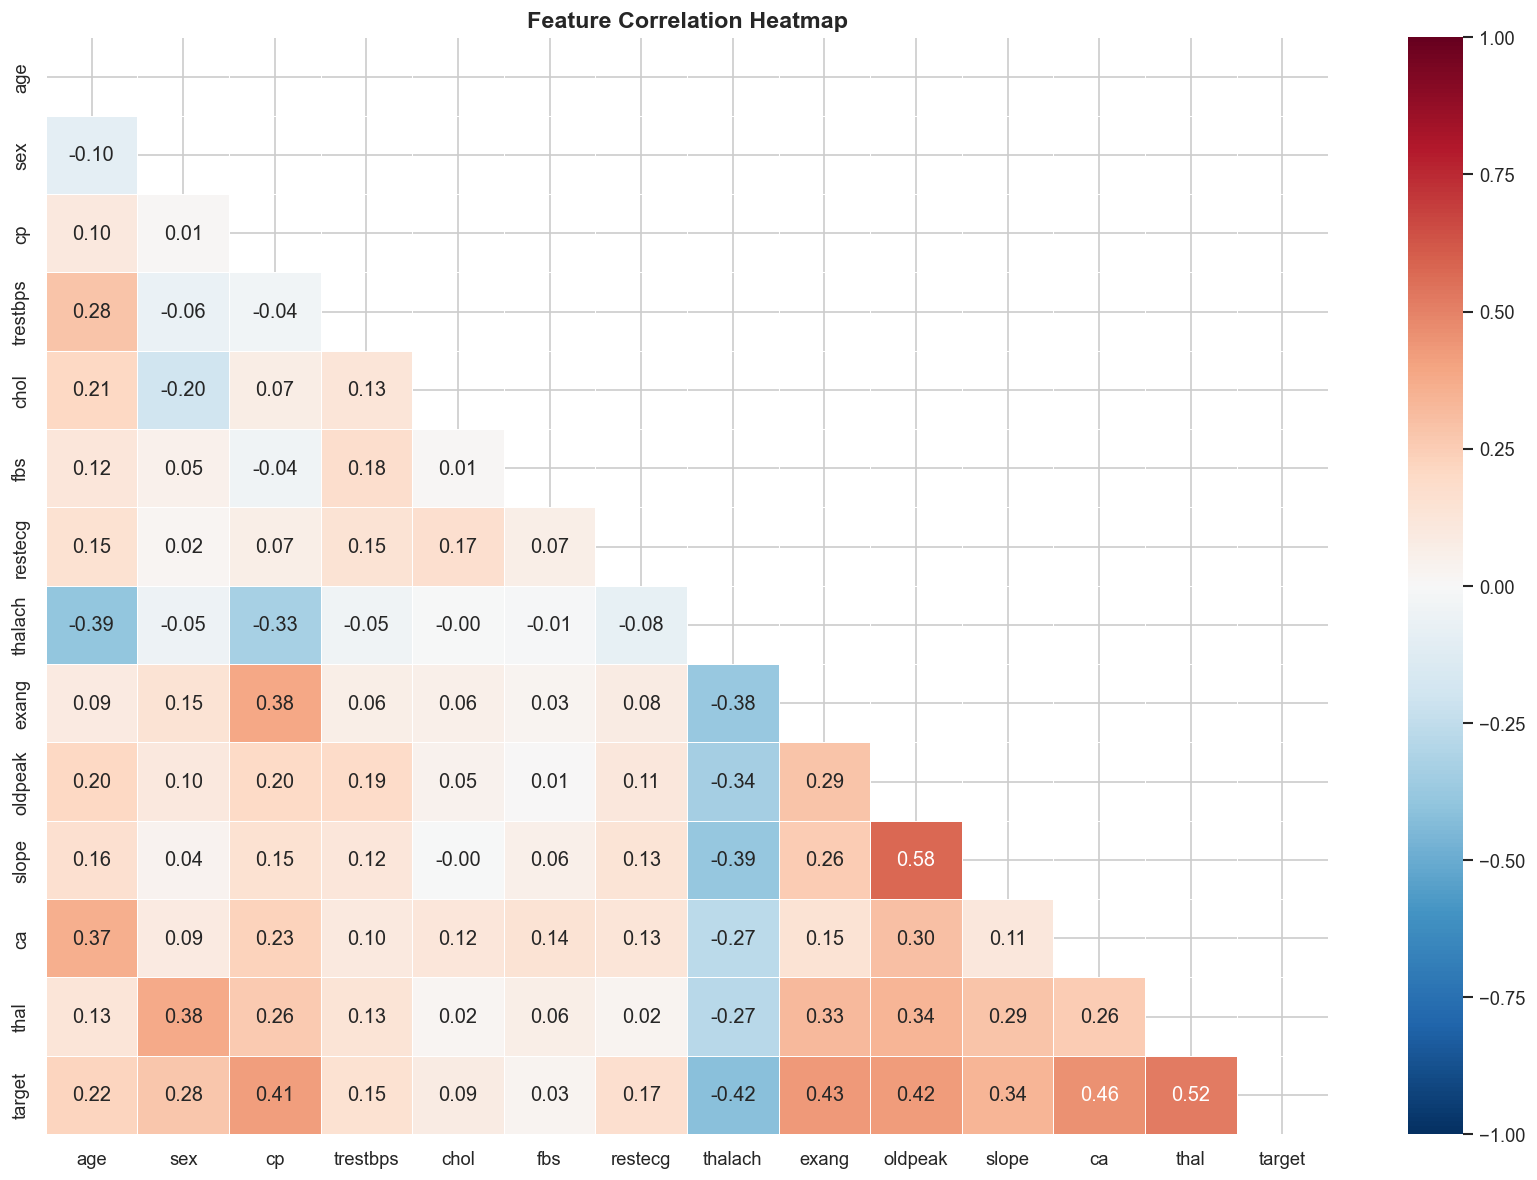

Top feature correlations with target:
  thal                : +0.522
  ca                  : +0.460
  exang               : +0.432
  oldpeak             : +0.425
  thalach             : -0.417
  cp                  : +0.414
  slope               : +0.339
  sex                 : +0.277
  age                 : +0.223
  restecg             : +0.169
  trestbps            : +0.151
  chol                : +0.085
  fbs                 : +0.025


In [11]:
# --- Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top correlations with target
print("Top feature correlations with target:")
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
for feat, corr in target_corr.items():
    print(f"  {feat:20s}: {corr_matrix['target'][feat]:+.3f}")

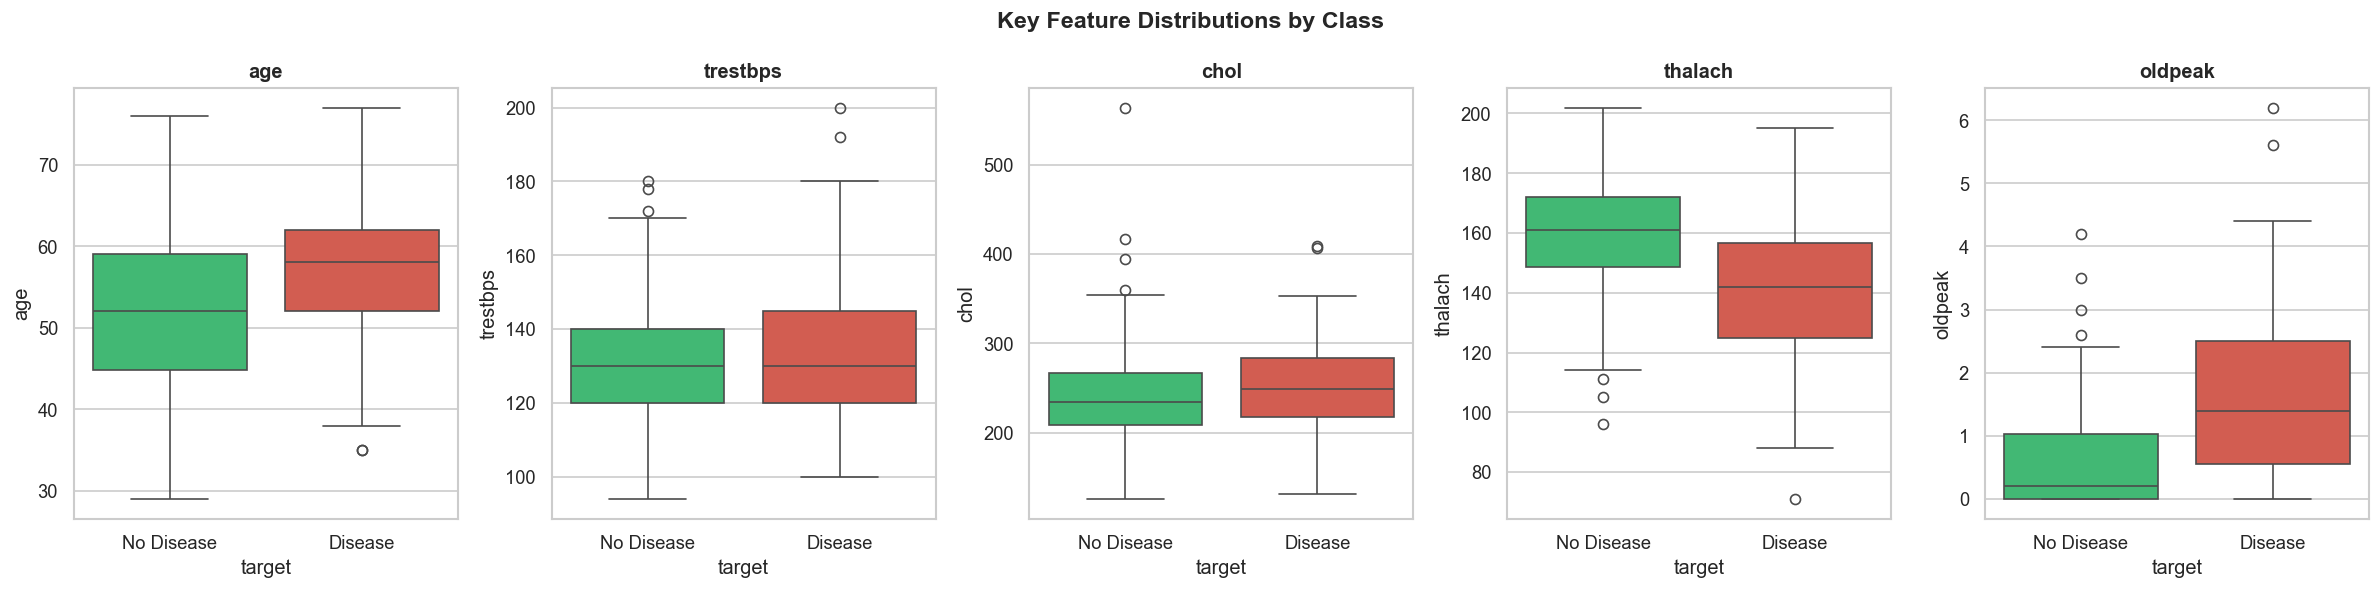

In [12]:
# --- Box Plots for Key Features ---
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
# Filter to only features that exist in the dataset
key_features = [f for f in key_features if f in df.columns]

if key_features:
    fig, axes = plt.subplots(1, len(key_features), figsize=(4 * len(key_features), 5))
    if len(key_features) == 1:
        axes = [axes]
    for i, col in enumerate(key_features):
        sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette=colors)
        axes[i].set_xticklabels(['No Disease', 'Disease'])
        axes[i].set_title(col, fontweight='bold')
    plt.suptitle('Key Feature Distributions by Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('screenshots/boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Task 2: Feature Engineering & Model Development
---

### 2.1 Feature Preparation (Scaling & Encoding)

In [13]:
# Separate features and target
feature_cols = [c for c in df.columns if c != 'target']
X = df[feature_cols].copy()
y = df['target'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")

Features shape: (303, 13)
Target shape: (303,)
Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Train set: 242 samples
Test set:  61 samples


In [14]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied (StandardScaler).")
print(f"Train mean (should be ~0): {X_train_scaled.mean(axis=0).round(2)[:5]}...")
print(f"Train std  (should be ~1): {X_train_scaled.std(axis=0).round(2)[:5]}...")

Feature scaling applied (StandardScaler).
Train mean (should be ~0): [-0.  0.  0. -0.  0.]...
Train std  (should be ~1): [1. 1. 1. 1. 1.]...


### 2.2 Model Training & Cross-Validation

In [15]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED)
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, model in models.items():
    scores = {
        'accuracy': cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy'),
        'precision': cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='precision'),
        'recall': cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='recall'),
        'f1': cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1'),
        'roc_auc': cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    }
    cv_results[name] = {metric: (vals.mean(), vals.std()) for metric, vals in scores.items()}
    print(f"\n{name}:")
    for metric, (mean, std) in cv_results[name].items():
        print(f"  {metric:12s}: {mean:.4f} (+/- {std:.4f})")


Logistic Regression:
  accuracy    : 0.8264 (+/- 0.0172)
  precision   : 0.8441 (+/- 0.0337)
  recall      : 0.7652 (+/- 0.0547)
  f1          : 0.8007 (+/- 0.0260)
  roc_auc     : 0.8960 (+/- 0.0148)

Random Forest:
  accuracy    : 0.8016 (+/- 0.0169)
  precision   : 0.8148 (+/- 0.0562)
  recall      : 0.7470 (+/- 0.0808)
  f1          : 0.7741 (+/- 0.0258)
  roc_auc     : 0.8802 (+/- 0.0324)

Gradient Boosting:
  accuracy    : 0.7809 (+/- 0.0507)
  precision   : 0.7655 (+/- 0.0604)
  recall      : 0.7565 (+/- 0.0624)
  f1          : 0.7598 (+/- 0.0543)
  roc_auc     : 0.8426 (+/- 0.0074)


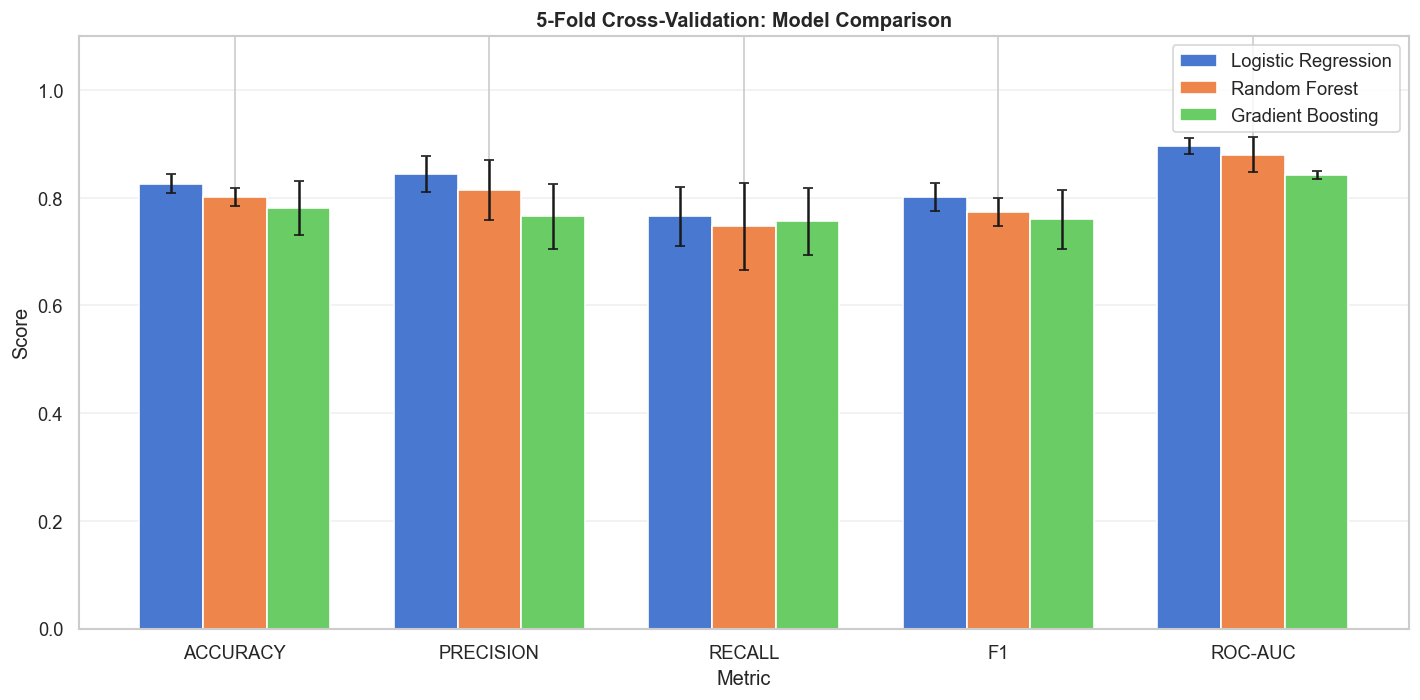

In [16]:
# Cross-validation comparison bar chart
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
model_names = list(cv_results.keys())

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, name in enumerate(model_names):
    means = [cv_results[name][m][0] for m in metrics_to_plot]
    stds = [cv_results[name][m][1] for m in metrics_to_plot]
    ax.bar(x + i * width, means, width, yerr=stds, label=name, capsize=3)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('5-Fold Cross-Validation: Model Comparison', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([m.upper().replace('_', '-') for m in metrics_to_plot])
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('screenshots/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Model Evaluation on Test Set

In [17]:
# Train all models on full training set and evaluate on test set
test_results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    test_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }
    trained_models[name] = model

    print(f"\n{'='*50}")
    print(f"{name} - Test Set Results")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
    for metric, value in test_results[name].items():
        print(f"  {metric:12s}: {value:.4f}")


Logistic Regression - Test Set Results
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

  accuracy    : 0.8689
  precision   : 0.8125
  recall      : 0.9286
  f1          : 0.8667
  roc_auc     : 0.9513

Random Forest - Test Set Results
              precision    recall  f1-score   support

  No Disease       0.96      0.82      0.89        33
     Disease       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61

  accuracy    : 0.8852
  precision   : 0.8182
  recall      : 0.9643
  f1          : 0.8852
  roc_auc     : 0.9513

Gradient Boosting - Test Set Results
    

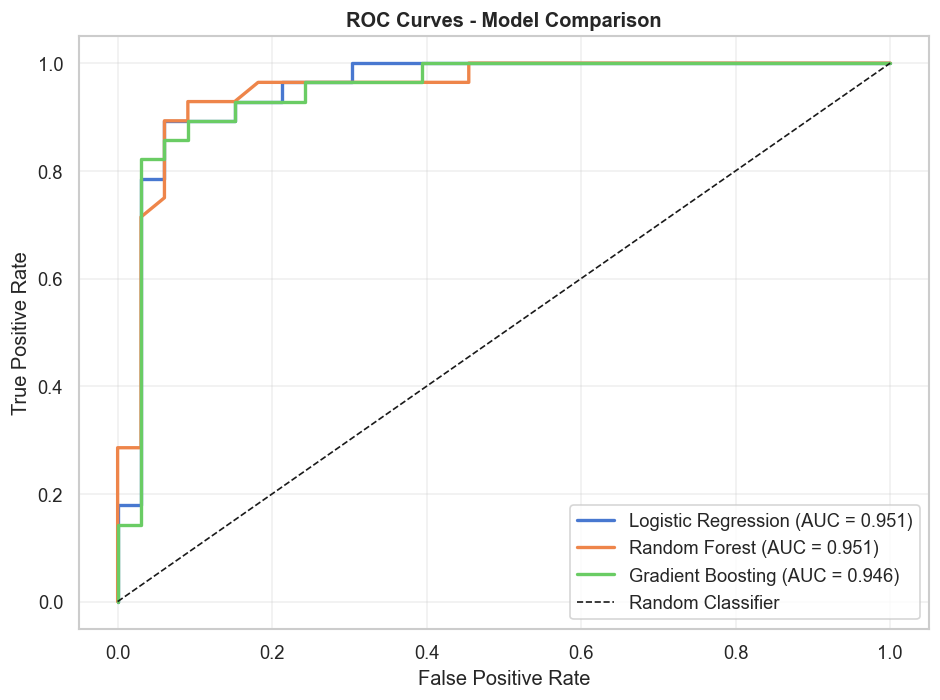

In [18]:
# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Model Comparison', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('screenshots/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

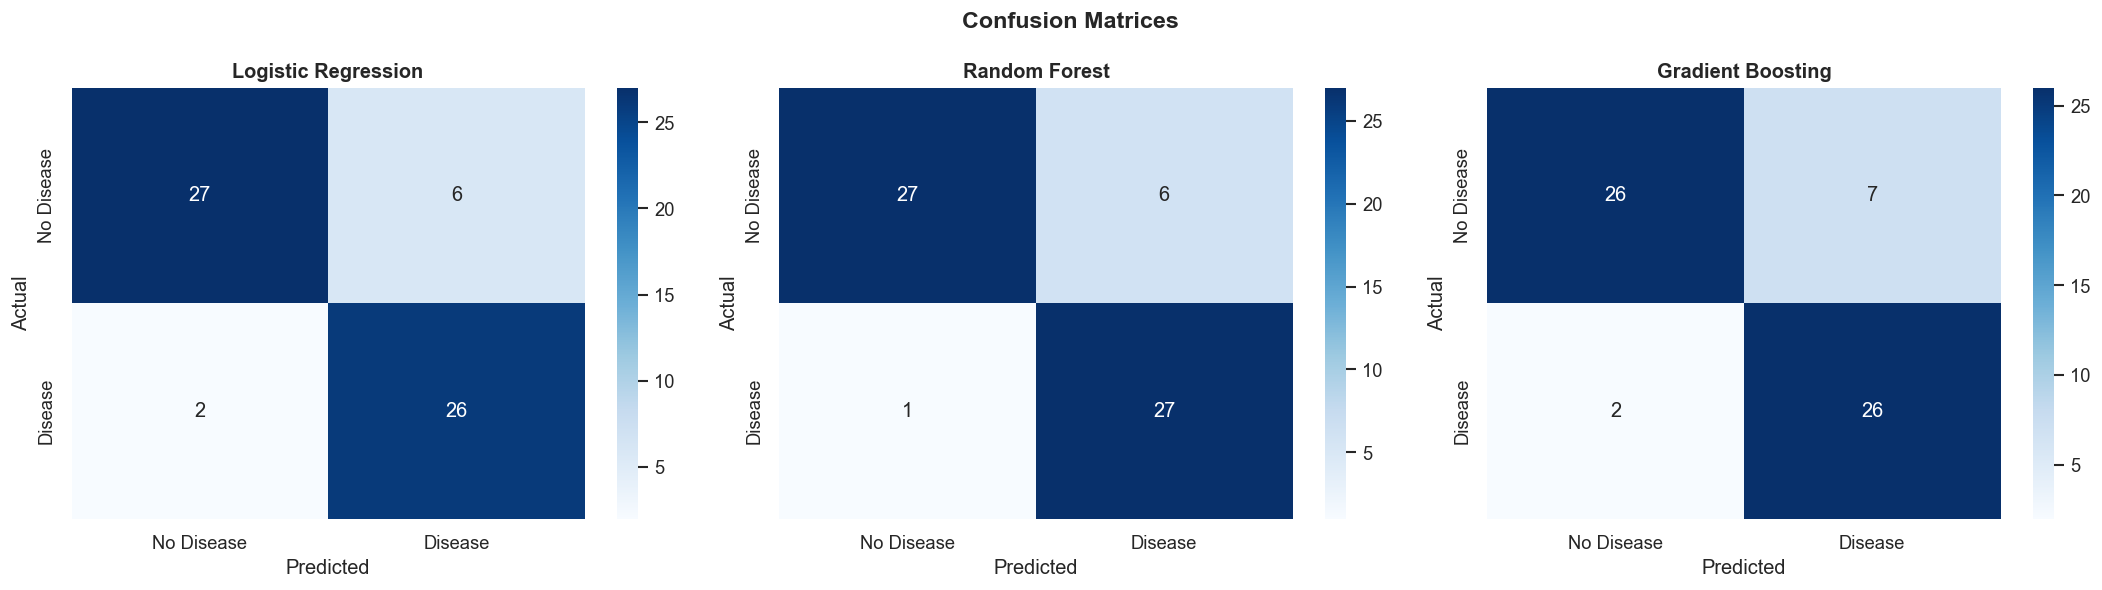

In [19]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, len(trained_models), figsize=(6 * len(trained_models), 5))
if len(trained_models) == 1:
    axes = [axes]

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Model Selection

In [20]:
# Select best model based on ROC-AUC
best_model_name = max(test_results, key=lambda k: test_results[k]['roc_auc'])
best_model = trained_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"\nTest set metrics:")
for metric, value in test_results[best_model_name].items():
    print(f"  {metric:12s}: {value:.4f}")

Best model: Logistic Regression

Test set metrics:
  accuracy    : 0.8689
  precision   : 0.8125
  recall      : 0.9286
  f1          : 0.8667
  roc_auc     : 0.9513


---
## Task 3: Experiment Tracking with MLflow
---

In [21]:
# Set up MLflow experiment
mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment('Heart_Disease_Classification')

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment: Heart_Disease_Classification")

2026/05/04 18:23:14 INFO mlflow.tracking.fluent: Experiment with name 'Heart_Disease_Classification' does not exist. Creating a new experiment.


MLflow tracking URI: file:./mlruns
Experiment: Heart_Disease_Classification


In [22]:
# Log all model experiments to MLflow
for name, model_instance in models.items():
    with mlflow.start_run(run_name=name):
        # Train model
        model_instance.fit(X_train_scaled, y_train)
        y_pred = model_instance.predict(X_test_scaled)
        y_proba = model_instance.predict_proba(X_test_scaled)[:, 1]

        # Log parameters
        params = model_instance.get_params()
        for param_name, param_value in params.items():
            try:
                mlflow.log_param(param_name, param_value)
            except Exception:
                pass  # Skip non-serializable params

        # Log metrics
        mlflow.log_metric('accuracy', accuracy_score(y_test, y_pred))
        mlflow.log_metric('precision', precision_score(y_test, y_pred))
        mlflow.log_metric('recall', recall_score(y_test, y_pred))
        mlflow.log_metric('f1_score', f1_score(y_test, y_pred))
        mlflow.log_metric('roc_auc', roc_auc_score(y_test, y_proba))

        # Log CV metrics
        for metric, (mean, std) in cv_results[name].items():
            mlflow.log_metric(f'cv_{metric}_mean', mean)
            mlflow.log_metric(f'cv_{metric}_std', std)

        # Log model
        mlflow.sklearn.log_model(model_instance, artifact_path='model')

        # Log plots as artifacts
        for plot_file in ['screenshots/roc_curves.png', 'screenshots/confusion_matrices.png',
                          'screenshots/cv_comparison.png']:
            if os.path.exists(plot_file):
                mlflow.log_artifact(plot_file)

        print(f"Logged {name} -> AUC: {roc_auc_score(y_test, y_proba):.4f}")

print("\nAll experiments logged to MLflow!")
print("Run 'mlflow ui' in the MLops/ directory to view the dashboard.")

2026/05/04 18:23:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 18:23:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/04 18:23:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 18:23:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Logged Logistic Regression -> AUC: 0.9513


2026/05/04 18:23:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 18:23:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged Random Forest -> AUC: 0.9513
Logged Gradient Boosting -> AUC: 0.9459

All experiments logged to MLflow!
Run 'mlflow ui' in the MLops/ directory to view the dashboard.


---
## Task 4: Model Packaging & Reproducibility
---

In [23]:
# Create a full preprocessing + model pipeline for the best model
# This ensures full reproducibility

# Rebuild as a single sklearn Pipeline
if best_model_name == 'Logistic Regression':
    final_estimator = LogisticRegression(max_iter=1000, random_state=SEED)
elif best_model_name == 'Random Forest':
    final_estimator = RandomForestClassifier(n_estimators=100, random_state=SEED)
else:
    final_estimator = GradientBoostingClassifier(n_estimators=100, random_state=SEED)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', final_estimator)
])

# Fit the full pipeline on training data
pipeline.fit(X_train, y_train)

# Verify pipeline performance matches
y_pred_pipeline = pipeline.predict(X_test)
y_proba_pipeline = pipeline.predict_proba(X_test)[:, 1]
print(f"Pipeline test accuracy: {accuracy_score(y_test, y_pred_pipeline):.4f}")
print(f"Pipeline test ROC-AUC:  {roc_auc_score(y_test, y_proba_pipeline):.4f}")

Pipeline test accuracy: 0.8689
Pipeline test ROC-AUC:  0.9513


In [24]:
# Save the pipeline (pickle format)
with open('model_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print("Model pipeline saved to 'model_pipeline.pkl'")

# Save feature names for inference
model_metadata = {
    'feature_names': feature_cols,
    'target_name': 'target',
    'model_type': best_model_name,
    'training_samples': len(X_train),
    'test_accuracy': float(accuracy_score(y_test, y_pred_pipeline)),
    'test_roc_auc': float(roc_auc_score(y_test, y_proba_pipeline))
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print("Model metadata saved to 'model_metadata.json'")

# Verify: load and predict
with open('model_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

sample = X_test.iloc[:3]
preds = loaded_pipeline.predict(sample)
probs = loaded_pipeline.predict_proba(sample)[:, 1]
print(f"\nVerification - predictions on 3 test samples:")
print(f"  Predictions:   {preds.tolist()}")
print(f"  Probabilities: {[round(p, 3) for p in probs.tolist()]}")
print(f"  Actual:        {y_test.iloc[:3].tolist()}")

Model pipeline saved to 'model_pipeline.pkl'
Model metadata saved to 'model_metadata.json'

Verification - predictions on 3 test samples:
  Predictions:   [0, 1, 0]
  Probabilities: [0.218, 0.709, 0.058]
  Actual:        [0, 0, 0]


In [25]:
# Also log the best model pipeline to MLflow
with mlflow.start_run(run_name=f'Best_Model_{best_model_name}'):
    mlflow.log_param('model_type', best_model_name)
    mlflow.log_param('pipeline', 'StandardScaler + Classifier')
    mlflow.log_metric('test_accuracy', accuracy_score(y_test, y_pred_pipeline))
    mlflow.log_metric('test_roc_auc', roc_auc_score(y_test, y_proba_pipeline))
    mlflow.sklearn.log_model(pipeline, artifact_path='pipeline')
    mlflow.log_artifact('model_pipeline.pkl')
    mlflow.log_artifact('model_metadata.json')
    mlflow.log_artifact('heart_disease_cleaned.csv')
    print(f"Best model pipeline logged to MLflow!")

2026/05/04 18:24:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 18:24:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best model pipeline logged to MLflow!
